# Fase 1 — Mortalidad quirúrgica: EDA + baseline (`sqlpvd_all`)

Segundo modelo, cohorte de **cirugía**, usando las tablas alternativas pedidas.

- **Cohorte / features**: `sqlpvd_all` (formulario perioperatorio, 449 cols):
  factores de riesgo `FR_*` + situación clínica `SC_*` + edad + creatinina.
  Demografía (sexo) por join a `pac_ficha` (`CodPac = Cod`).
- **Target**: **mortalidad a 30 días** — `fallecio = 1` si el paciente figura en
  el registro `sqlsalud_fallece` con `Fecha` dentro de los 30 días posteriores a
  `FechaRealizado`. Base rate ≈ 6.7%.
- **Encoding**: flags `FR_*`/`SC_*` con `255 = "sí"` (igual convención que PTCA).

**Notas de datos (de la exploración):**
- El outcome sale de **`sqlsalud_fallece`** (registro con fecha de muerte, causa
  y join `NroHistoria = pac_ficha.Cod = sqlpvd_all.CodPac`, 100% de match). A
  diferencia del desenlace del formulario, **tiene fecha real y cubre años
  recientes** (2023–2026) → no hace falta corte temporal artificial.
- Coincide con el desenlace del formulario (~6.5%), lo que valida ambos.
- `salud_paciente` NO tiene fecha de muerte; `pac_ficha.Fallecio` es "falleció
  alguna vez" (mortalidad de por vida, ~13%), no del acto.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymysql
from pymysql.cursors import DictCursor

DB = dict(
    host=os.getenv("INCC_MYSQL_HOST", "190.64.90.170"),
    port=int(os.getenv("INCC_MYSQL_PORT", "8809")),
    user=os.getenv("INCC_MYSQL_USER", "proyecto"),
    password=os.getenv("INCC_MYSQL_PASSWORD", "proyecto"),
    database=os.getenv("INCC_MYSQL_DB", "incc"),
)


def read_sql(sql: str) -> pd.DataFrame:
    conn = pymysql.connect(cursorclass=DictCursor, autocommit=True, read_timeout=120, **DB)
    try:
        with conn.cursor() as cur:
            cur.execute(sql)
            return pd.DataFrame(cur.fetchall())
    finally:
        conn.close()


print("Conectando a", DB["host"], ":", DB["port"], "/", DB["database"])

Conectando a 190.64.90.170 : 8809 / incc


## 1. Extracción del dataset (cirugía)

In [2]:
# Features binarias (FR_* factores de riesgo, SC_* situación clínica al ingreso).
FR_FLAGS = [
    "FR_Cig", "FR_Hiper", "FR_Diab", "FR_Obeso", "FR_Dislipemia", "FR_AVE",
    "FR_Eceva", "FR_EPOC", "FR_FallaRen", "FR_IRC", "FR_AF", "FR_Apnea",
]
SC_FLAGS = [
    "SC_IAM", "SC_Shock", "SC_BIAC", "SC_Arritmia", "SC_Angina", "SC_Trombo", "SC_MP",
    "SC_Tapon", "SC_Cardia",
]
# Enriquecimiento (features pre-op con señal, del perfilado):
#  - Tipo/complejidad de cirugía y reintervención.
#  - Enfermedad valvular (dx pre-op).
PROC_FLAGS = [
    "Procedimiento_ByPass", "Procedimiento_Aortico", "Procedimiento_Mitral",
    "Procedimiento_Tricuspide", "Procedimiento_Combinado",
    "IP_CCprevio", "CCHemo_EnfermedadAO", "CCHemo_EnfermedadMI",
    "DatosCC_CondicionesIAM",  # IAM reciente pre-op
]
FLAGS = FR_FLAGS + SC_FLAGS + PROC_FLAGS

# Target: mortalidad a 30 días vía registro de fallecimientos CON FECHA
# (sqlsalud_fallece.NroHistoria = pac_ficha.Cod = sqlpvd_all.CodPac).
# Ventaja sobre el desenlace del formulario: fecha real + cubre años recientes.
flag_cols = ",\n    ".join(f"s.{c}" for c in FLAGS)
SQL = f"""
SELECT
    s.Cod                    AS cod_pvd,
    s.EdadCoo                AS edad,
    pf.CodSexo               AS sexo,
    s.FR_Crea                AS creatinina,
    s.CCHemo_Eyeccion        AS fe,
    s.DatosCEC_HematocritoPre AS hto_pre,
    s.CCHemo_VasosAfectados  AS vasos,
    s.MP_NYHA                AS nyha,
    s.Anestesia_ClasificacionRiesgo AS asa,
    s.DatosCC_CodCirugiaClase AS clase_cirugia,
    s.CodCoordinaReglaMotivo AS prioridad,
    s.CCHemo_InsuficienciaMI AS insuf_mi,
    YEAR(s.FechaRealizado)   AS anio,
    {flag_cols},
    CASE WHEN sf.Fecha > '1900-01-01'
              AND DATEDIFF(sf.Fecha, s.FechaRealizado) BETWEEN 0 AND 30
         THEN 1 ELSE 0 END   AS fallecio
FROM sqlpvd_all s
LEFT JOIN pac_ficha pf       ON pf.Cod = s.CodPac
LEFT JOIN sqlsalud_fallece sf ON sf.NroHistoria = s.CodPac
WHERE s.FechaRealizado > '1900-01-01'
"""

df = read_sql(SQL)
print("Dataset:", df.shape)
df.head()

Dataset: (14592, 44)


,cod_pvd,edad,sexo,creatinina,fe,hto_pre,vasos,nyha,asa,clase_cirugia,...,Procedimiento_ByPass,Procedimiento_Aortico,Procedimiento_Mitral,Procedimiento_Tricuspide,Procedimiento_Combinado,IP_CCprevio,CCHemo_EnfermedadAO,CCHemo_EnfermedadMI,DatosCC_CondicionesIAM,fallecio
0,97,55,1,0.00,40,39,0,3,3,1,...,0,0,0,0,0,255,0,0,0,0
1,98,48,2,1.00,68,39,0,2,2,1,...,0,255,0,0,0,0,255,0,0,0
2,99,59,2,1.19,40,39,0,3,3,1,...,0,255,0,0,255,0,255,0,0,0
3,100,46,2,1.00,45,41,3,1,2,1,...,255,0,0,0,0,255,0,0,0,0
4,101,62,2,1.00,50,42,3,1,2,1,...,255,0,0,0,0,0,0,0,0,0


## 2. Limpieza, encoding y filtro temporal

- Flags `FR_*`/`SC_*`: `255 = "sí"` → 1; resto → 0.
- Edad: capear `[0, 110]`. Creatinina: negativos/extremos → NaN (rango 0.1–20).
- Sexo: `0` = sin dato → NaN.
- Sin corte temporal (el registro de muertes cubre años recientes); solo se
  descartan cargas anteriores a 2005.

In [3]:
# Mortalidad por año ANTES de filtrar (para ver el corte de outcomes).
pre = df.groupby("anio")["fallecio"].agg(n="count", muertes="sum")
pre["mort_%"] = (pre["muertes"] / pre["n"] * 100).round(2)
print("Mortalidad por año (cruda):")
print(pre.tail(15).to_string())

# Encoding de flags: 255 = "sí".
for col in FLAGS:
    df[col] = (df[col] == 255).astype(int)

# Edad y creatinina.
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
df.loc[(df["edad"] < 0) | (df["edad"] > 110), "edad"] = np.nan
df["creatinina"] = pd.to_numeric(df["creatinina"], errors="coerce")
df.loc[(df["creatinina"] <= 0) | (df["creatinina"] > 20), "creatinina"] = np.nan

# Numéricas nuevas: rangos plausibles (0/-1 = sin dato -> NaN).
df["fe"] = pd.to_numeric(df["fe"], errors="coerce")
df.loc[(df["fe"] <= 5) | (df["fe"] > 90), "fe"] = np.nan          # fracción de eyección
df["hto_pre"] = pd.to_numeric(df["hto_pre"], errors="coerce")
df.loc[(df["hto_pre"] <= 10) | (df["hto_pre"] > 60), "hto_pre"] = np.nan
df["vasos"] = pd.to_numeric(df["vasos"], errors="coerce")
df.loc[(df["vasos"] < 0) | (df["vasos"] > 5), "vasos"] = np.nan   # vasos coronarios afectados
df["nyha"] = pd.to_numeric(df["nyha"], errors="coerce")
df.loc[(df["nyha"] < 1) | (df["nyha"] > 4), "nyha"] = np.nan      # 0 = sin dato
df["asa"] = pd.to_numeric(df["asa"], errors="coerce")
df.loc[(df["asa"] < 1) | (df["asa"] > 6), "asa"] = np.nan         # clasificación de riesgo
df["insuf_mi"] = pd.to_numeric(df["insuf_mi"], errors="coerce")
df.loc[(df["insuf_mi"] < 0) | (df["insuf_mi"] > 4), "insuf_mi"] = np.nan  # severidad 0-4

# Sexo, clase de cirugía y prioridad: categóricas object con np.nan (evita pd.NA).
def as_cat(series, na_values=()):
    s = pd.to_numeric(series, errors="coerce")
    s = s.where(~s.isin(na_values), np.nan)
    return s.apply(lambda v: str(int(v)) if pd.notna(v) else np.nan).astype(object)

df["sexo"] = as_cat(df["sexo"], na_values=[0])
df["clase_cirugia"] = as_cat(df["clase_cirugia"], na_values=[0])  # 0 = sin dato

# Prioridad (CodCoordinaReglaMotivo): motivos frecuentes + "otro".
prio = pd.to_numeric(df["prioridad"], errors="coerce")
top_prio = prio.value_counts().nlargest(4).index  # 109, 105, 120, 106
df["prioridad"] = as_cat(prio.where(prio.isin(top_prio), other=-1))

# El registro de muertes cubre años recientes -> NO hace falta corte temporal.
df = df[df["anio"] >= 2005].copy()  # descartar cargas viejas/ruidosas

n = len(df)
pos = int(df["fallecio"].sum())
print(f"\nDataset final -> {n:,} filas | {pos} muertes a 30d ({100 * pos / n:.2f}%)")

Mortalidad por año (cruda):
        n  muertes  mort_%
anio                      
2012  491       37    7.54
2013  476       44    9.24
2014  444       34    7.66
2015  376       21    5.59
2016  436       39    8.94
2017  396       39    9.85
2018  425       36    8.47
2019  407       43   10.57
2020  292       22    7.53
2021  285       20    7.02
2022  335       21    6.27
2023  305       23    7.54
2024  287       23    8.01
2025  259       25    9.65
2026   42        3    7.14

Dataset final -> 9,355 filas | 685 muertes a 30d (7.32%)


## 3. EDA: prevalencias y asociación cruda con la muerte

In [4]:
prev = (df[FLAGS].mean() * 100).sort_values(ascending=False).round(1)
print("Prevalencia de features (% de 'sí'):")
print(prev.to_string())

rows = []
for col in FLAGS:
    grp = df.groupby(col)["fallecio"].mean() * 100
    rows.append({
        "feature": col,
        "mort_si_%": round(grp.get(1, np.nan), 2),
        "mort_no_%": round(grp.get(0, np.nan), 2),
        "n_si": int((df[col] == 1).sum()),
    })
assoc = pd.DataFrame(rows)
assoc["lift"] = (assoc["mort_si_%"] / assoc["mort_no_%"]).round(2)
assoc.sort_values("lift", ascending=False)

Prevalencia de features (% de 'sí'):
FR_Hiper                    65.1
Procedimiento_ByPass        56.6
FR_Dislipemia               55.7
SC_Angina                   48.0
Procedimiento_Aortico       35.1
SC_Cardia                   34.4
CCHemo_EnfermedadAO         33.0
FR_Diab                     25.2
FR_Cig                      23.9
FR_Obeso                    22.3
SC_IAM                      18.7
FR_AF                       18.5
CCHemo_EnfermedadMI         12.9
Procedimiento_Mitral        12.7
IP_CCprevio                  8.0
SC_Arritmia                  7.5
FR_EPOC                      6.6
DatosCC_CondicionesIAM       3.6
FR_FallaRen                  3.4
FR_AVE                       3.2
Procedimiento_Tricuspide     1.9
FR_Eceva                     1.4
FR_IRC                       1.1
Procedimiento_Combinado      0.8
SC_Shock                     0.7
FR_Apnea                     0.7
SC_MP                        0.7
SC_Trombo                    0.6
SC_BIAC                      0.4
SC_Tap

,feature,mort_si_%,mort_no_%,n_si,lift
19,SC_Tapon,43.48,7.23,23,6.01
13,SC_Shock,40.58,7.08,69,5.73
14,SC_BIAC,38.10,7.18,42,5.31
9,FR_IRC,27.27,7.11,99,3.84
8,FR_FallaRen,17.81,6.95,320,2.56
6,FR_Eceva,15.38,7.21,130,2.13
26,IP_CCprevio,13.94,6.75,746,2.07
25,Procedimiento_Combinado,14.10,7.27,78,1.94
18,SC_MP,13.85,7.28,65,1.90
29,DatosCC_CondicionesIAM,12.68,7.12,339,1.78


## 4. Split temporal + baseline (regresión logística)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

TEST_FROM_YEAR = int(df["anio"].quantile(0.75))
train = df[df["anio"] < TEST_FROM_YEAR].copy()
test = df[df["anio"] >= TEST_FROM_YEAR].copy()
print(f"Cutoff test = año >= {TEST_FROM_YEAR}")
print(f"Train: {len(train):,} | {int(train['fallecio'].sum())} muertes ({train['fallecio'].mean()*100:.2f}%)")
print(f"Test : {len(test):,} | {int(test['fallecio'].sum())} muertes ({test['fallecio'].mean()*100:.2f}%)")

NUMERIC = ["edad", "creatinina", "fe", "hto_pre", "vasos", "nyha", "asa", "insuf_mi"]
CATEG = ["sexo", "clase_cirugia", "prioridad"]
BINARY = FLAGS
FEATURES = NUMERIC + CATEG + BINARY

X_train, y_train = train[FEATURES], train["fallecio"]
X_test, y_test = test[FEATURES], test["fallecio"]

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), CATEG),
    ("bin", SimpleImputer(strategy="constant", fill_value=0), BINARY),
])
model = Pipeline([("pre", pre), ("lr", LogisticRegression(class_weight="balanced", max_iter=2000))])
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
print("Modelo entrenado. Test:", proba.shape)

Cutoff test = año >= 2018
Train: 6,718 | 469 muertes (6.98%)
Test : 2,637 | 216 muertes (8.19%)


Modelo entrenado. Test: (2637,)


## 5. Métricas + curvas + odds ratios

=== Métricas en TEST ===
Base rate           : 8.19%
AUC-ROC             : 0.713
AUC-PR              : 0.223  (azar=0.082)
Brier               : 0.2246


CV AUC-ROC (train)  : [0.718 0.731 0.699 0.736 0.745]  media 0.726

Umbral Youden=0.583
Matriz confusión [real x pred]:
[[1903  518]
 [  99  117]]

               precision    recall  f1-score   support

           0      0.951     0.786     0.861      2421
           1      0.184     0.542     0.275       216

    accuracy                          0.766      2637
   macro avg      0.567     0.664     0.568      2637
weighted avg      0.888     0.766     0.813      2637



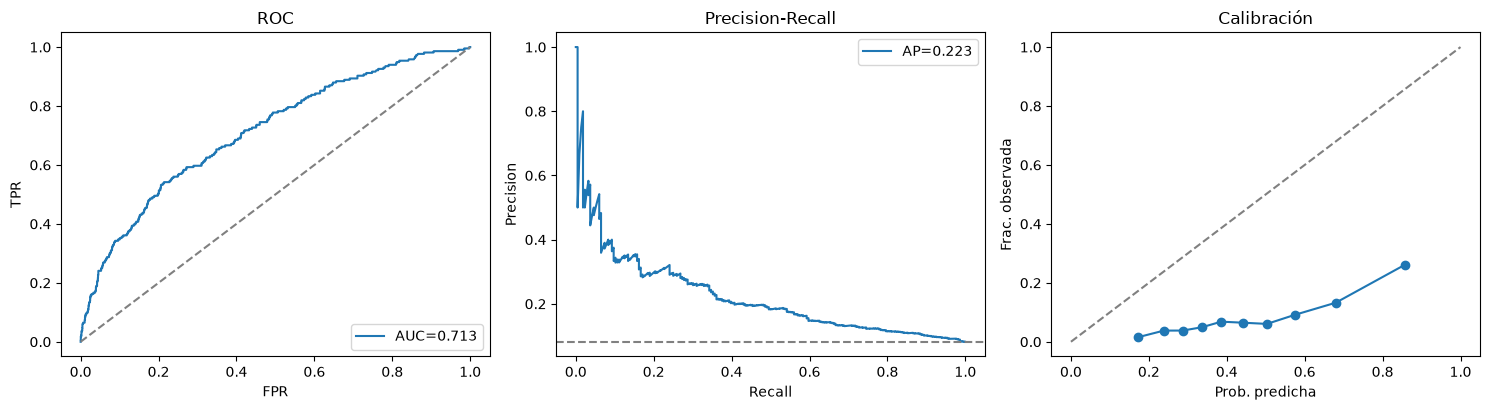

,feature,coef,odds_ratio
0,bin__SC_Trombo,-0.989917,0.372
1,bin__FR_Apnea,-0.863662,0.422
2,cat__clase_cirugia_3,0.824018,2.280
3,bin__IP_CCprevio,0.744035,2.104
4,bin__FR_FallaRen,0.714351,2.043
5,bin__SC_Tapon,0.692530,1.999
6,bin__Procedimiento_Mitral,0.647215,1.910
7,cat__clase_cirugia_1,-0.576469,0.562
8,bin__Procedimiento_Aortico,0.573830,1.775
9,bin__Procedimiento_Combinado,0.555437,1.743


In [6]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.calibration import calibration_curve

base_rate = y_test.mean()
print("=== Métricas en TEST ===")
print(f"Base rate           : {base_rate*100:.2f}%")
print(f"AUC-ROC             : {roc_auc_score(y_test, proba):.3f}")
print(f"AUC-PR              : {average_precision_score(y_test, proba):.3f}  (azar={base_rate:.3f})")
print(f"Brier               : {brier_score_loss(y_test, proba):.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV AUC-ROC (train)  : {cv_auc.round(3)}  media {cv_auc.mean():.3f}")

fpr, tpr, thr = roc_curve(y_test, proba)
best_thr = thr[np.argmax(tpr - fpr)]
pred = (proba >= best_thr).astype(int)
print(f"\nUmbral Youden={best_thr:.3f}\nMatriz confusión [real x pred]:")
print(confusion_matrix(y_test, pred))
print("\n", classification_report(y_test, pred, digits=3))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, proba):.3f}"); ax[0].plot([0,1],[0,1],"--",color="gray")
ax[0].set(xlabel="FPR", ylabel="TPR", title="ROC"); ax[0].legend(loc="lower right")
prec, rec, _ = precision_recall_curve(y_test, proba)
ax[1].plot(rec, prec, label=f"AP={average_precision_score(y_test, proba):.3f}"); ax[1].axhline(base_rate, ls="--", color="gray")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall"); ax[1].legend(loc="upper right")
fp, mp = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
ax[2].plot(mp, fp, "o-"); ax[2].plot([0,1],[0,1],"--",color="gray")
ax[2].set(xlabel="Prob. predicha", ylabel="Frac. observada", title="Calibración")
plt.tight_layout(); plt.show()

feat_names = model.named_steps["pre"].get_feature_names_out()
coefs = model.named_steps["lr"].coef_[0]
imp = pd.DataFrame({"feature": feat_names, "coef": coefs})
imp["odds_ratio"] = np.exp(imp["coef"]).round(3)
imp.reindex(imp["coef"].abs().sort_values(ascending=False).index).head(20).reset_index(drop=True)

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Comparación honesta: modelo no lineal (Gradient Boosting) vs logística,
# misma partición temporal y mismo preprocesamiento.
pre_gb = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), CATEG),
    ("bin", SimpleImputer(strategy="constant", fill_value=0), BINARY),
])
gb = Pipeline([
    ("pre", pre_gb),
    ("gb", HistGradientBoostingClassifier(
        learning_rate=0.05, max_depth=3, max_iter=400,
        l2_regularization=1.0, class_weight="balanced", random_state=42)),
])
gb.fit(X_train, y_train)
proba_gb = gb.predict_proba(X_test)[:, 1]

cv_gb = cross_val_score(gb, X_train, y_train, cv=cv, scoring="roc_auc")

print("                        LogReg     GradBoost")
print(f"AUC-ROC (test)   :      {roc_auc_score(y_test, proba):.3f}      {roc_auc_score(y_test, proba_gb):.3f}")
print(f"AUC-PR  (test)   :      {average_precision_score(y_test, proba):.3f}      {average_precision_score(y_test, proba_gb):.3f}")
print(f"Brier   (test)   :      {brier_score_loss(y_test, proba):.4f}     {brier_score_loss(y_test, proba_gb):.4f}")
print(f"CV AUC-ROC (train):     {cv_auc.mean():.3f}      {cv_gb.mean():.3f}")
print(f"  (azar AUC-PR = {base_rate:.3f})")

                        LogReg     GradBoost
AUC-ROC (test)   :      0.713      0.701
AUC-PR  (test)   :      0.223      0.200
Brier   (test)   :      0.2246     0.1974
CV AUC-ROC (train):     0.726      0.712
  (azar AUC-PR = 0.082)


## 6. Conclusiones

- **Funciona el enfoque `sqlpvd_all`**: target self-contained (~6.5% mortalidad
  intrahospitalaria) y features clínicamente sensatas.
- Discriminación **AUC ≈ 0.66** (CV ≈ 0.68): por encima del azar pero **más
  débil que PTCA** (0.82). Odds ratios correctos: shock ×4.8, IRC ×2, BIAC ×2.1.
- **Solo se usaron ~20 de 449 columnas.** Para mejorar: sumar tipo de cirugía,
  fracción de eyección, clase NYHA, prioridad/urgencia, valvular vs CRM y labs.

**Datos**: `salud_paciente` no tiene fecha de muerte; el outcome sale de
`sqlpvd_all` (`CondicionAlta_CausaFallecimiento*`). Años ≥ 2023 sin outcome
cargado → excluidos.

**Siguiente iteración**: ampliar features desde las 449 columnas de `sqlpvd_all`
antes de decidir si productivizar cirugía o quedarnos con PTCA (más fuerte).